<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>


# **Loading Images in Keras**


## **CNN Training Pipeline**


Convolutional neural networks (CNNs) have had great success in certain kinds of problems, such as image recognition. Data loading and preparation are important steps when it comes to working with such models. Increasingly, data augmentation is also required for more complex object recognition tasks. In this lab, we will discover various ways of loading images, as well as converting, augmenting and saving image datasets using the Keras API.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/cnn_image_loading_lab.drawio.png)


### **What's a Digital Image?**


A gray-scale digital image can be interpreted as a rectangular array of numbers. If we zoom into the region, we see the image is comprised of a rectangular grid of discrete blocks called pixels. We can represent these pixels with numbers called intensity values ranging from 0 to 255, as shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/Gray_scale_lana.png)


Color images are a combination of red, blue, and green intensity values as shown here


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/RGB_ape.png)


each channel has  values ranging from 0 to 255.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/RGB_array.png)


Finally, to apply a neural network to Karis we sometimes add a batch dimension, this is just  an extra dimension. Just think of the batch dimension as an address that contains an image array.


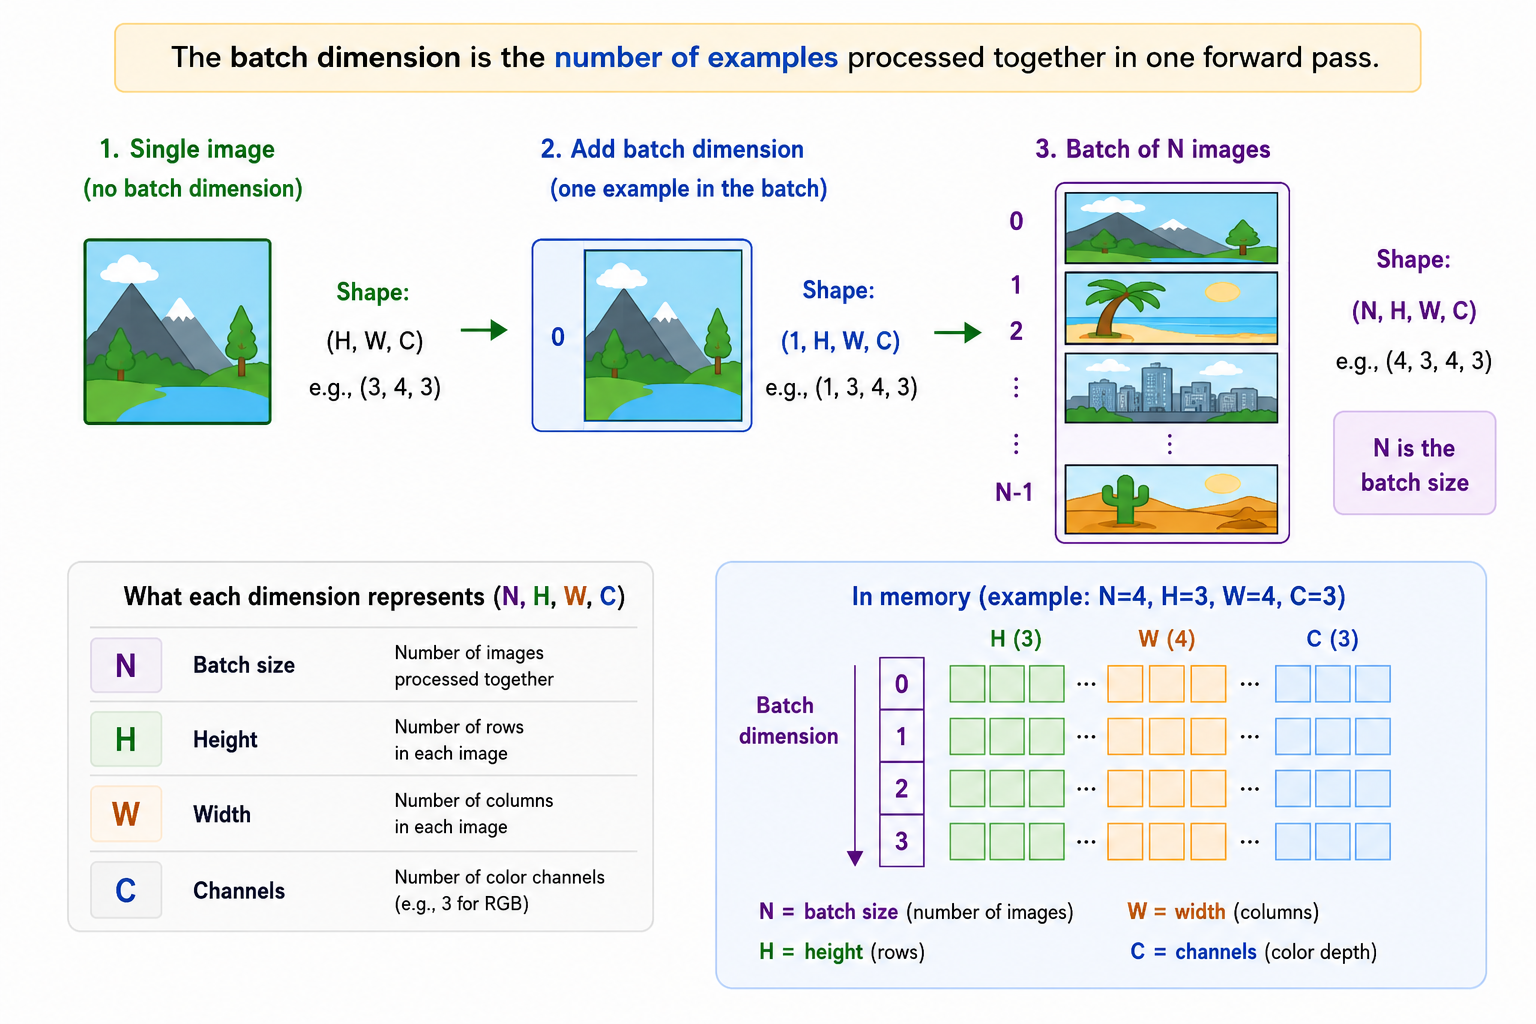

## **Table of Contents**

1. [Objectives](#toc-objectives)
2. [Setup](#toc-setup)
    1. [Installing Required Libraries](#toc-installing-required-libraries)
    2. [Importing Required Libraries](#toc-importing-required-libraries)
    3. [Defining Helper Functions](#toc-defining-helper-functions)
3. [Background](#toc-background)
4. [Ways to load images](#toc-ways-to-load-images)
    1. [A. Ready-to-use toy datasets](#toc-a-ready-to-use-toy-datasets)
        1. [Using image data with Autoencoders](#toc-using-image-data-with-autoencoders)
    2. [Exercise 1 - Load Fashion MNIST](#toc-exercise-1-load-fashion-mnist)
    3. [Exercise 2 - Load CIFAR100 with coarse label_mode](#toc-exercise-2-load-cifar100-with-coarse-labelmode)
    4. [B. Load individual images as PIL objects](#toc-b-load-individual-images-as-pil-objects)
        1. [Converting an image](#toc-converting-an-image)
        2. [Saving an image](#toc-saving-an-image)
    5. [C. Load from directory of images](#toc-c-load-from-directory-of-images)
        1. [Visualizing images](#toc-visualizing-images)
    6. [Exercise 3 - Load validation set from the directory](#toc-exercise-3-load-validation-set-from-the-directory)
        1. [Augmenting Images](#toc-augmenting-images)
    7. [Exercise 4 - Visualizing augmented images](#toc-exercise-4-visualizing-augmented-images)
    8. [D. Load image from URL](#toc-d-load-image-from-url)

## **Objectives** <a id="toc-objectives"></a>

After completing this lab you will be able to **apply** Keras to:

*   Load and display images in multiple ways
*   Convert between array and PIL formats
*   Convert images to grayscale, augment images through transformations and save images to files


## **Setup** <a id="toc-setup"></a>


For this lab, we will be using the following libraries:

*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`Pillow`](https://pillow.readthedocs.io/en/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for image processing functions.
*   [`OpenCV`](https://docs.opencv.org/4.x/index.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for other image processing functions.
*   [`tensorflow`](https://www.tensorflow.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and neural network related functions.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.
*   [`keras`](https://keras.io/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for building artificial neural networks.


### **Installing Required Libraries** <a id="toc-installing-required-libraries"></a>

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [108]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
#!pip install numpy==1.22.3 matplotlib==3.5.1 tensorflow==2.9.0 opencv-python==4.5.5.62 keras

# Note: If your environment doesn't support "!mamba install", use "!pip install --user"

# RESTART YOUR KERNEL AFTERWARD AS WELL

In [109]:
#!pip3 install --upgrade tensorflow

# RESTART YOUR KERNEL AFTERWARD AS WELL

### **Importing Required Libraries** <a id="toc-importing-required-libraries"></a>

*We recommend you import all required libraries in one place (here):*


In [ ]:
# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass


import warnings

warnings.warn = warn
warnings.filterwarnings("ignore")

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = (
    "2"  # tensorflow INFO and WARNING messages are not printed
)

In [111]:
import random 

import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import PIL
import PIL.Image
from PIL import Image, ImageOps
import tensorflow as tf

import keras
from keras.preprocessing import image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img 
from keras.models import Model
from keras.layers import Input, Dense

import cv2

sns.set_context('notebook')
sns.set_style('white')

### **Defining Helper Functions** <a id="toc-defining-helper-functions"></a>


In [ ]:
# This function will allow us to visualize four sample images from the loaded toy image dataset.
def visualize(X_train):
    plt.rcParams["figure.figsize"] = (6, 6)

    for i in range(4):
        plt.subplot(2, 2, i + 1)
        num = random.randint(0, len(X_train))
        plt.imshow(
            X_train[num], cmap="gray", interpolation="none", vmin=0, vmax=255
        )
        plt.title("class {}".format(y_train[num]))

    plt.tight_layout()

## **Background** <a id="toc-background"></a>


Keras is an open-source Python library used for developing and evaluating deep learning models. It provides utilities for loading, preparing, converting, augmenting, and saving image data. In this lab, we will explore various ways of loading image datasets in Keras.


In [113]:
# Print tensorflow version
print(tf.__version__)

# Try !pip install --upgrade tensorflow if the version printed
# is less than 2.9.0

2.20.0


## **Ways to load images** <a id="toc-ways-to-load-images"></a>


We will look into four main ways of using image datasets in Keras:

*   Loading in a ready-to-use toy dataset from [Keras](https://keras.io/api/datasets/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)
*   Loading individual images as PIL objects
*   Reading a directory of images on disk using `tf.keras.utils.image_dataset_from_directory`.
*   Loading image from URL


### **A. Ready-to-use toy datasets** <a id="toc-a-ready-to-use-toy-datasets"></a>


The `tf.keras.datasets` in Keras provide a few in-built image datasets that have been cleaned and are typically helpful in debugging models, or creating simple examples.

These include MNIST hand-written digits, Fashion MNIST, CIFAR10, and CIFAR100.


**MNIST hand-written digits** is a collection of 60,000 28x28 grayscale images belonging to 10 different classes, along with a test set of 10,000 images. Let us load in the MNIST hand-written digits dataset using the `load_data` function.


In [114]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train is a uint8 numpy array of grayscale images with shapes (60000, 28, 28) from the training dataset. Its pixel values range from 0 to 255.

y_train is a uint8 numpy array of digit labels (integers in range 0-9) with shape (60000) for the training data.


In [115]:
print(X_train.shape)
print(X_train.dtype)
print(y_train.shape)
print(y_train.dtype)

(60000, 28, 28)
uint8
(60000,)
uint8


Let's visualize four random images from the training set. Only one color channel is needed to display the image as a grayscale. So for this step, we take a single color channel and display the image using the `plt.imshow()` method with `cmap` set to `gray`, `vmin` set to 0, and `vmax` set to 255.


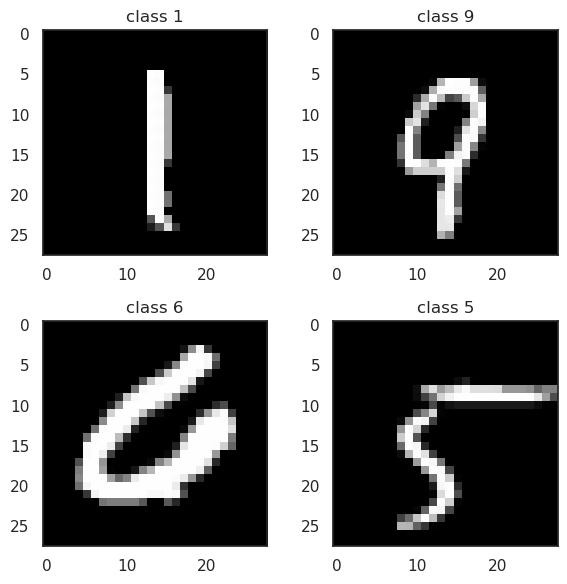

In [116]:
visualize(X_train)

#### **Using image data with Autoencoders** <a id="toc-using-image-data-with-autoencoders"></a>


An Autoencoder (AE) is a type of neural network that learns to reconstruct its own input. In other words, the model receives the input data and tries to generate an output that is as similar as possible to the original input.

An autoencoder contains two main parts:

1. An **encoder**, which compresses the input data into a smaller representation  
2. A **decoder**, which reconstructs the original data from the compressed representation  

During training, the model minimizes a loss function that measures the difference between the original input and the reconstructed output.

Autoencoders are commonly used for tasks such as image denoising, dimensionality reduction, and feature extraction.

In this example, the original image has 784 input features, corresponding to a flattened $28 \times 28$ image:

$$
28 \times 28 = 784
$$

The encoder compresses the image into a smaller latent representation with only 64 dimensions:

```python
ENCODING_DIM = 64
```

The compressed representation is created using a `Dense` layer:

```python
encoded = Dense(ENCODING_DIM, activation="sigmoid")(inputs)
```

The decoder then reconstructs the original 784-dimensional image from this compressed representation:

```python
reconstruction = Dense(784, activation="sigmoid")(encoded_inputs)
```

As shown below:

- `encoded` has shape `(None, 64)`
- `reconstruction` has shape `(None, 784)`

This means the model learns how to represent the original image using a much smaller set of features while still preserving the important information needed for reconstruction.

In [ ]:
ENCODING_DIM = 64

# Encoded representations:
inputs = Input(shape=(784,))
encoded = Dense(ENCODING_DIM, activation="sigmoid")(inputs)

# Reconstructions:
encoded_inputs = Input(shape=(ENCODING_DIM,), name="encoding")
reconstruction = Dense(784, activation="sigmoid")(encoded_inputs)

print("Encoded Input: ", encoded.shape)
print("Reconstructed Input: ", reconstruction.shape)

Encoded Input:  (None, 64)
Reconstructed Input:  (None, 784)


Using this architecture, we can build three related models.

The first model is the complete **Autoencoder**, which takes the original input image, compresses it into a smaller representation, and then reconstructs the image from that compressed information.

The second model is the **Encoder**. This model only performs the compression step. It maps the original input into the latent space, which is the smaller compressed representation learned by the network.

The third model is the **Decoder**. Instead of taking the original image as input, it takes a point from the latent space and reconstructs the corresponding image.

In summary:

$$
Input \rightarrow Encoder \rightarrow Latent\ Space \rightarrow Decoder \rightarrow Reconstruction
$$

The full autoencoder performs the entire process, while the encoder and decoder can also be used separately.

### **Exercise 1 - Load Fashion MNIST** <a id="toc-exercise-1-load-fashion-mnist"></a>


**Fashion MNIST** is another collection of 60,000 28x28 grayscale images belonging to 10 different classes, along with a test set of 10,000 images. Write code to load the Fashion MNIST dataset using  `fashion_mnist.load_data()` from `keras.datasets`.


In [ ]:
# Write your code here
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

Now print the shape and dtype of the X_train and y_train arrays.


In [119]:
X_train.shape, y_train.shape

((60000, 28, 28), (60000,))

`X_train` is a NumPy array containing 60,000 grayscale training images with shape `(60000, 28, 28)`. Each image has a resolution of $28 \times 28$ pixels, and the pixel values range from 0 to 255.

`y_train` is a NumPy array containing the corresponding digit labels for the training images. It has shape `(60000,)`, and each label is an integer between 0 and 9.

Display a few randomly selected images as grayscale using the `visualize()` helper function.


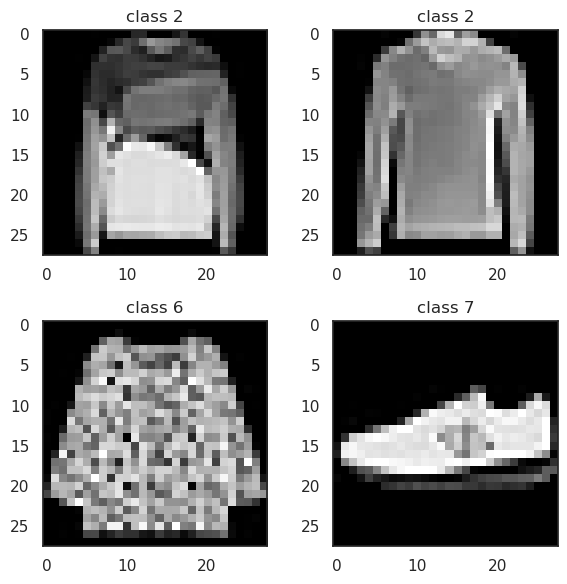

In [ ]:
# Write your code here
# Visualize a few images from the training set
visualize(X_train)

**CIFAR-10** is a smaller version of the dataset containing 10 image categories instead of 100. It also contains 50,000 training images and 10,000 test images, with each image having size $32 \times 32$ pixels.

Keras already provides predefined training and test sets:


In [121]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_train is a uint8 numpy array of grayscale image data with shapes (50000, 32, 32, 3), containing the training data. Pixel values range from 0 to 255.

y_train is a uint8 NumPy array of labels (integers in range 0-9) with shape (50000, 1) for the training data.


In [122]:
print(X_train.shape)
print(X_train.dtype)

(50000, 32, 32, 3)
uint8


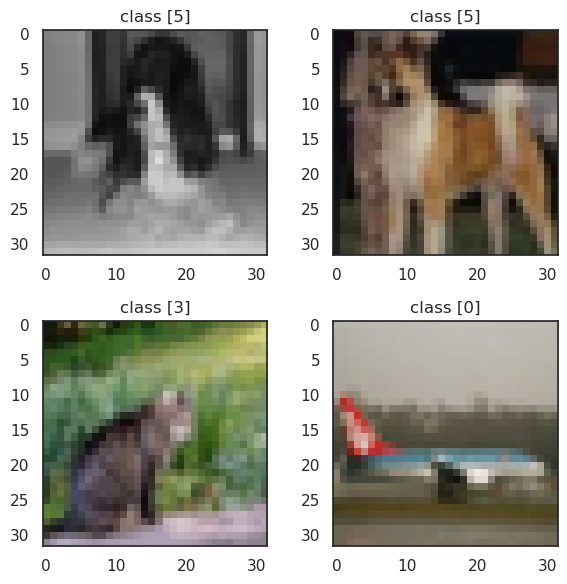

In [123]:
visualize(X_train)


**CIFAR-100** is an image dataset containing 50,000 training images and 10,000 test images. Each image is a $32 \times 32$ color image. The dataset contains 100 fine-grained classes, which are further grouped into 20 coarse-grained superclasses. Each image therefore has both a fine label and a superclass label.



Using the fine `label_mode`:


In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar100.load_data(
    label_mode="fine"
)

X_train is a uint8 numpy array of grayscale image data with shapes (50000, 32, 32, 3), containing the training data. Pixel values range from 0 to 255.

y_train is a uint8 numpy array of labels (integers in range 0-99) with shape (50000, 1) for the training data.


In [125]:
print(X_train.shape)
print(X_train.dtype)

(50000, 32, 32, 3)
uint8


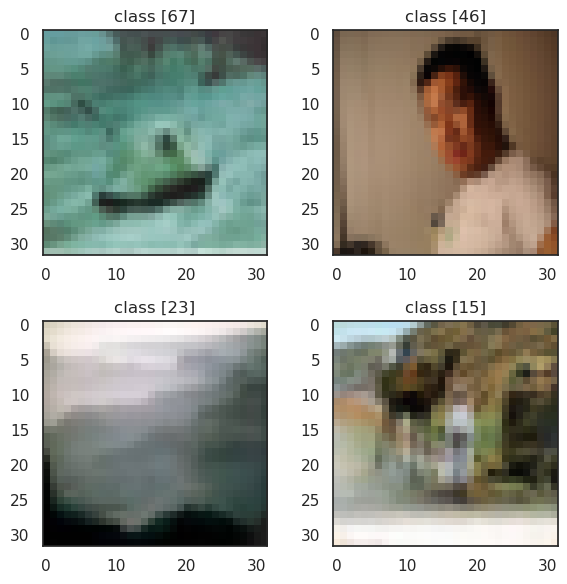

In [126]:
visualize(X_train)

### **Exercise 2 - Load CIFAR100 with coarse label_mode** <a id="toc-exercise-2-load-cifar100-with-coarse-labelmode"></a>


Load the CIFAR100 dataset by setting the pramter ```label_mode = 'coarse'``` in the ```load_data``` function .


In [ ]:
# Write your solution here
# Load the Fashion CIFAR100 dataset using the coarse label_mode
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar100.load_data(
    label_mode="coarse"
)

Visualize a few images from the training set using the `visualize()` helper function.


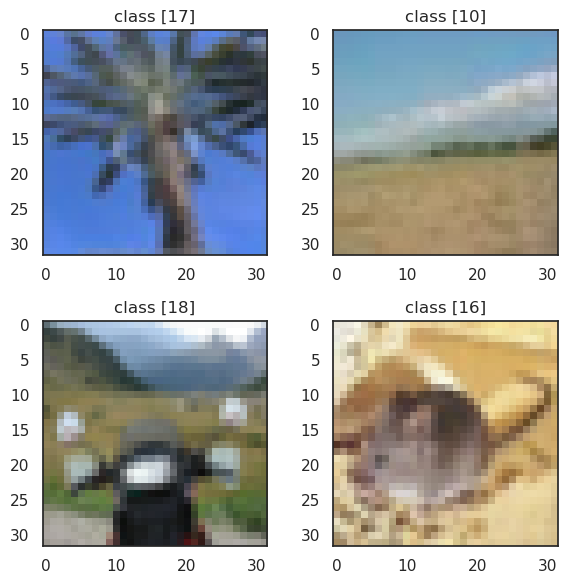

In [ ]:
# Write your solution here
visualize(X_train)

### **B. Load individual images as PIL objects** <a id="toc-b-load-individual-images-as-pil-objects"></a>



In this section, we use TensorFlow and Pillow utilities to load images as PIL image objects.

We will save the following image into our working environment.


In [ ]:
import requests

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/Dog_Breeds.jpg"
filename = URL.split("/")[-1]
r = requests.get(URL, allow_redirects=True)
open(filename, "wb").write(r.content)

70761

Next, we will specify a `target_size` of the image using a tuple of ints.


In [130]:
img_height, img_width = 100, 100

Using the path of the image we saved, we will use the `load_img` function to return a PIL Image instance.

The `load_img()` function loads the image file and returns a PIL image object.

The argument `target_size=(img_height, img_width)` resizes the image to a fixed size, which is important because neural networks usually require all input images to have the same dimensions.

The `color_mode` argument controls the image format:

- `"grayscale"` loads the image with a single intensity channel
- `"rgb"` loads the image with three color channels: red, green, and blue

The `interpolation='nearest'` argument specifies the resizing method used when scaling the image.


In [ ]:
gray_img = load_img(
    "Dog_Breeds.jpg",
    target_size=(img_height, img_width),
    interpolation="nearest",
    color_mode="grayscale",
)

color_img = load_img(
    "Dog_Breeds.jpg",
    target_size=(img_height, img_width),
    interpolation="nearest",
    color_mode="rgb",
)

## We can confirm that the loaded objects are PIL images using:
print(type(gray_img))
print(type(color_img))

<class 'PIL.Image.Image'>
<class 'PIL.Image.Image'>


We can plot each image 


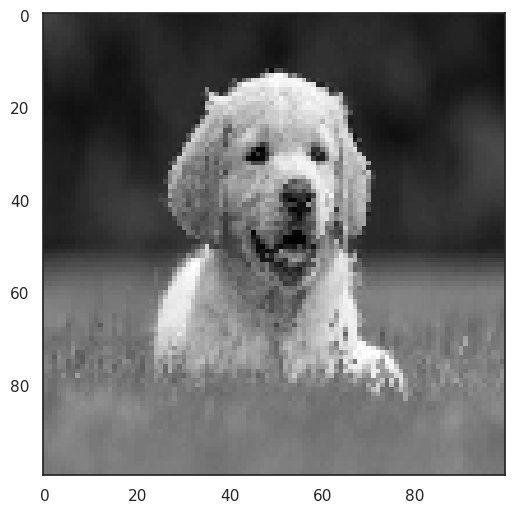

In [ ]:
plt.imshow(gray_img, cmap="gray")
plt.show()

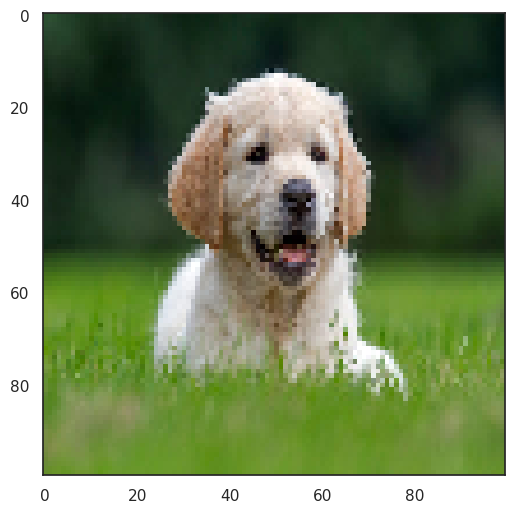

In [133]:
plt.imshow(color_img)
plt.show()

#### **Converting an image** <a id="toc-converting-an-image"></a>


Neural networks cannot directly process PIL image objects, so the image must first be converted into a numerical array.

We can convert the PIL image to a 3D numpy array of pixel data, and a single image to a batch using the following code:


In [ ]:
input_arr = tf.keras.preprocessing.image.img_to_array(color_img)

# we inspect the shape of the loaded image.
print("image shape", input_arr.shape)

image shape (100, 100, 3)


The shape is $(100, 100, 3)$ which means that the image has a height of 100 pixels, a width of 100 pixels, and 3 color channels (red, green, blue).


Neural networks in TensorFlow are designed to process multiple images at the same time during training and prediction. This group of samples is called a **batch**.

Because of this, TensorFlow expects image data to have the shape:

$$
(batch\_size,\ height,\ width,\ channels)
$$

Even when we only use a single image, the model still expects a batch dimension. Therefore, we convert:

$$
(height,\ width,\ channels)
$$

into:

$$
(1,\ height,\ width,\ channels)
$$

where `1` means the batch contains one image.

**Convert single image to a batch**

For example:

```python
input_arr.shape
```

may return:

$$
(224,\ 224,\ 3)
$$

This represents one RGB image with height 224, width 224, and 3 color channels.

Before passing the image into a neural network, we must add an extra dimension representing the batch size. After conversion, the shape becomes:

$$
(1,\ 224,\ 224,\ 3)
$$

where `1` means the batch contains one image.

The first method:

```python
input_arr_batch = np.array([input_arr])
```

simply wraps the image inside a Python list and converts it into a batch array. The square brackets [] create a new outer container (a list), so NumPy adds one new dimension to represent that container.

The second method:

```python
input_arr_batch = input_arr.reshape(
    -1,
    input_arr.shape[0],
    input_arr.shape[1],
    input_arr.shape[2]
)

reshape(-1, h, w, c)
```

reshapes the array directly. The `-1` tells NumPy to automatically determine the batch size dimension.

In [ ]:
# Convert single image to a batch
input_arr_batch = np.array([input_arr])

# or
input_arr_batch = input_arr.reshape(
    -1, input_arr.shape[0], input_arr.shape[1], input_arr.shape[2]
)

In [ ]:
print("image shape plus batch dimension", input_arr_batch.shape)

image shape plus batch dimension (1, 100, 100, 3)


Similarly, we can convert a numpy array of pixel data back to an image.


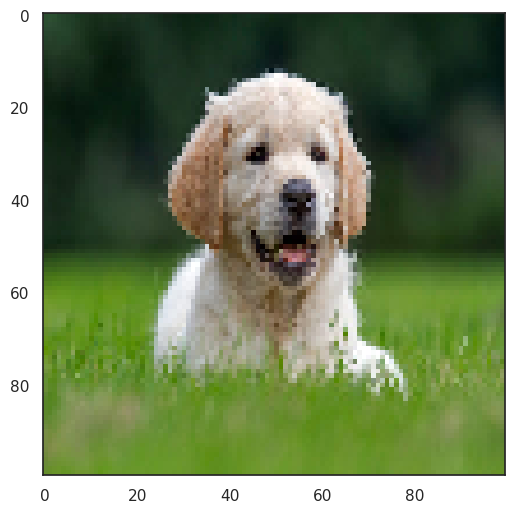

In [137]:
# Write your solution here
# Convert the numpy array back to an image
color_img = tf.keras.preprocessing.image.array_to_img(input_arr)
plt.imshow(color_img)
plt.show()

#### **Saving an image** <a id="toc-saving-an-image"></a>

saves the image stored in `color_img` to a new file named:

```python
dog_color_img.jpg
```

In other words:

- `color_img` = image data stored in memory
- `'dog_color_img.jpg'` = output filename on disk

In [ ]:
tf.keras.preprocessing.image.save_img("dog_color_img.jpg", color_img)

### **C. Load from directory of images** <a id="toc-c-load-from-directory-of-images"></a>


Keras provides several tools for loading image datasets. In this lab, we use `image_dataset_from_directory`, a modern TensorFlow utility that loads images directly from folders and returns a `tf.data.Dataset`. This approach works well with Keras preprocessing layers for rescaling and augmentation.

In this example, we will work with a flower dataset containing five categories:

| Category | Flower |
|---|---|
| 0 | Daisies |
| 1 | Dandelions |
| 2 | Roses |
| 3 | Sunflowers |
| 4 | Tulips |

Unlike datasets such as MNIST or CIFAR-10, this flower dataset is not built into Keras. Therefore, we first need to download it manually using:

```python
keras.utils.get_file()
```

The `keras.utils.get_file()` function downloads a file from a URL and stores it locally. It can also automatically extract compressed files such as `.zip` or `.tar.gz`.

For example:

```python
path = keras.utils.get_file(
    fname="flower_photos",
    origin=dataset_url,
    untar=True
)
```

Here:

- `fname` specifies the local folder name
- `origin` specifies the download URL
- `untar=True` automatically extracts the dataset after downloading

Difference between `keras.utils.get_file()` and `keras.datasets`:

`keras.datasets` provides several small built-in datasets that are already prepared and automatically split into training and test sets. For example:

```python
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
```

`keras.utils.get_file()` is a general downloading utility. It only downloads the dataset files and does not automatically create training or test sets. After downloading, we still need to load the images from the folders and prepare the dataset manually.

In [ ]:
import pathlib

dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/datasets/flower_photos.tgz"

# Download the data and track where it's saved using tf.keras.utils.get_file in a variable called data_dir
data_dir = keras.utils.get_file(
    origin=dataset_url, fname="flower_photos", untar=True
)
data_dir = pathlib.Path(data_dir)
if (data_dir / "flower_photos").is_dir():
    data_dir = data_dir / "flower_photos"

for folder in data_dir.glob("[!LICENSE]*"):
    print(
        "The",
        folder.name,
        "folder has",
        len(list(folder.glob("*.jpg"))),
        "pictures",
    )
image_count = len(list(data_dir.glob("*/*.jpg")))
print(image_count, "total images")

The roses folder has 641 pictures
The tulips folder has 799 pictures
The daisy folder has 633 pictures
The sunflowers folder has 699 pictures
The dandelion folder has 898 pictures
3670 total images


The files are stored in the following directory.

```python
flower_photos
    └── daisy
    └── dandelion
    └── roses
    └── sunflowers
    └── tulips

```


It seems there are a substantial amount of photos for each type of photo.

We can checkout some of the images below.


#### **Visualizing images** <a id="toc-visualizing-images"></a>


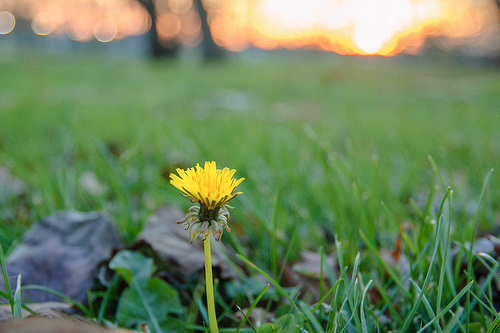

In [ ]:
dandelion = list(data_dir.glob("dandelion/*"))
PIL.Image.open(str(dandelion[1]))

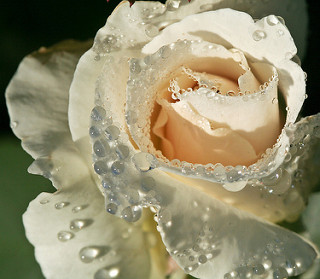

In [ ]:
roses = list(data_dir.glob("roses/*"))
PIL.Image.open(str(roses[1]))

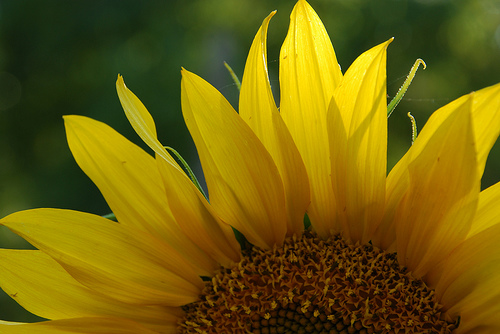

In [ ]:
sunflowers = list(data_dir.glob("sunflowers/*"))
PIL.Image.open(str(sunflowers[1]))

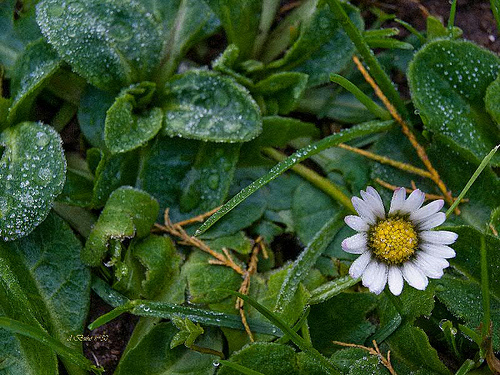

In [ ]:
daisy = list(data_dir.glob("daisy/*"))

PIL.Image.open(str(daisy[1]))

We can see that these photos are in various lighting conditions, framing, sizes, and zoom.


In [144]:
# The batch size simply specifies the number of images to pass through our neural network at a time, until the entire training set is passed through. 32 is the default
batch_size = 32

# Here we set the size of all the images to be 200x200
img_height = 200
img_width = 200

Here we split our images into training and validation sets using the `keras.utils.image_dataset_from_directory()` function.

*   Because our flower images are sorted into subfolders named after the type of flower, this method can automatically load in images and label them with the correct classes.
*   In order to plug these photos into our neural network as an input, we'll have to standardize the image sizes. We can do that with the `image_size` argument.


Let us use `image_dataset_from_directory` to load images off disk:


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


### **Exercise 3 - Load validation set from the directory** <a id="toc-exercise-3-load-validation-set-from-the-directory"></a>


Use the `image_dataset_from_directory` to load the validation set from the directory


In [ ]:
# Write your code here

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


We can show the class names 


In [147]:
class_names = train_ds.class_names
class_names

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Let's look at some sample rows from the dataset we loaded:


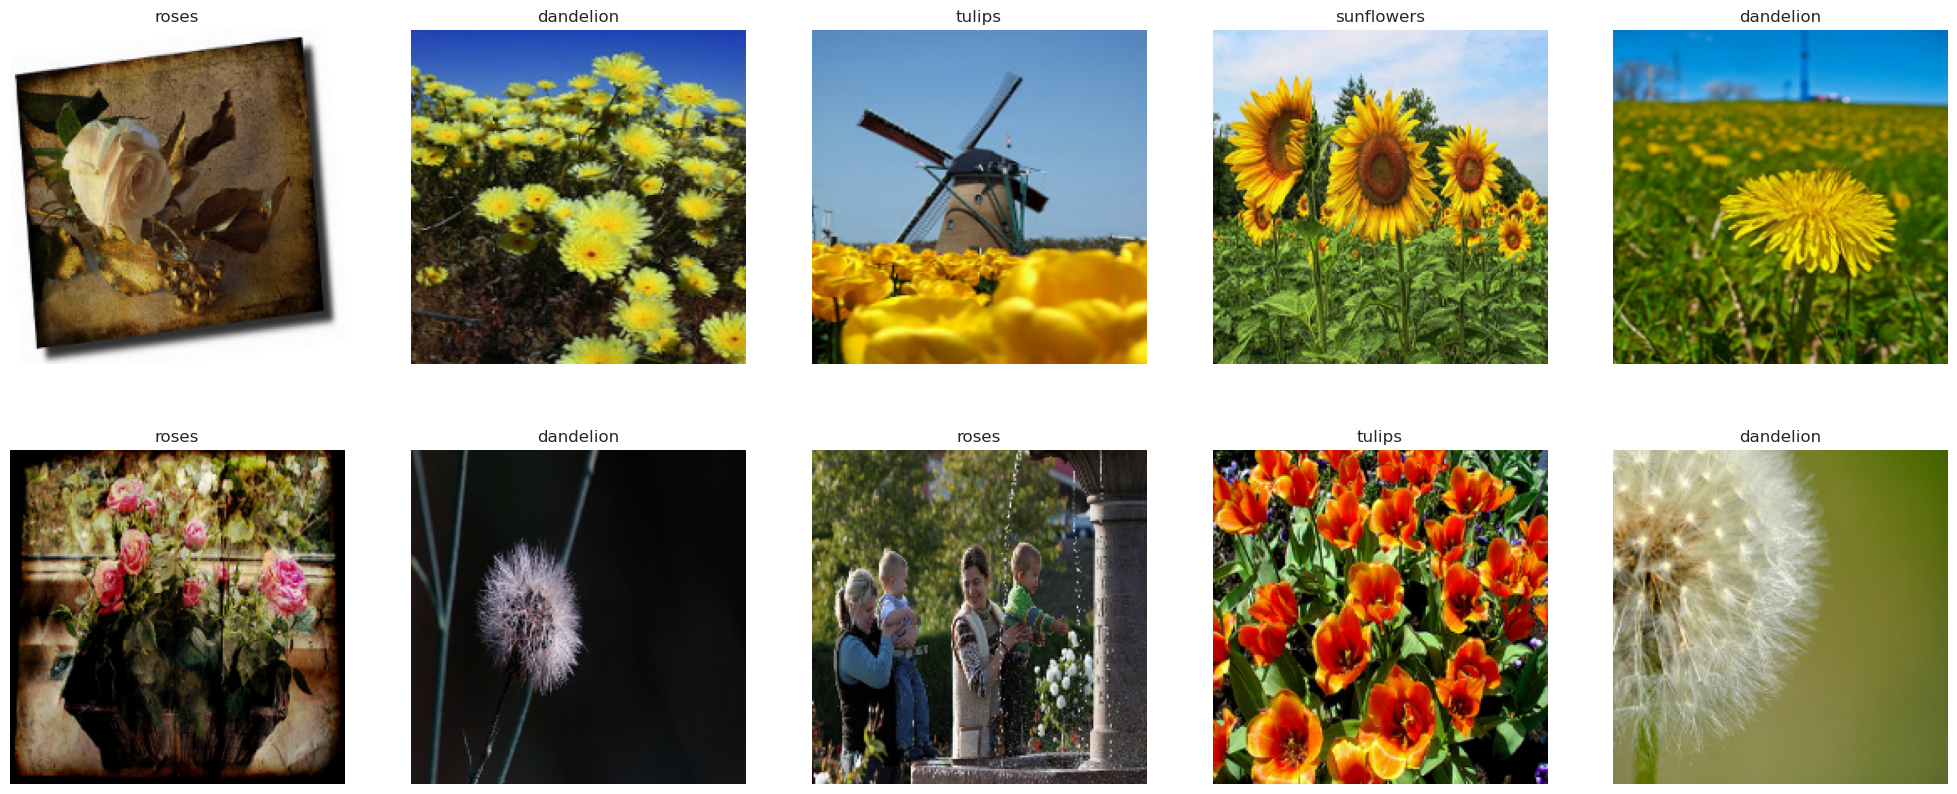

In [ ]:
# .take() will take the first batch from a tensorflow dataset.
# In our case it has taken the first 32 images.
first_batch = train_ds.take(1)

plt.figure(figsize=(25, 10))
for img, lbl in first_batch:
    # lets look at the first 10 images
    for i in np.arange(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(img[i].numpy().astype("uint8"))
        plt.title(class_names[lbl[i]])
        plt.axis("off")

We can see that after importing our images, they're all exactly square with `200 x 200` pixels.


#### **Augmenting Images** <a id="toc-augmenting-images"></a>


Next, we will use Keras preprocessing layers to augment the image dataset. This is the modern approach when images are loaded with `image_dataset_from_directory`, because the transformations can be included directly in the TensorFlow data pipeline or inside a model.

Image augmentation creates random variations of the training images, which can help the model generalize better. Common augmentation operations include:

*   **Rescaling**: converts pixel values from the 0-255 range to the 0-1 range
*   **RandomRotation**: randomly rotates images
*   **RandomTranslation**: randomly shifts images left/right or up/down
*   **RandomFlip**: randomly flips images vertically or horizontally

Further details on these options can be found in the TensorFlow documentation for [Keras preprocessing layers](https://www.tensorflow.org/guide/keras/preprocessing_layers).

In [149]:
data_augmentation = keras.Sequential(
    [
        layers.Rescaling(1.0 / 255),
        layers.RandomRotation(20 / 360),
        layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
        layers.RandomFlip("vertical"),
    ]
)

augmented_train_ds = train_ds.map(
    lambda images, labels: (data_augmentation(images, training=True), labels)
)

images, labels = next(iter(augmented_train_ds))

print(images.shape)
print(labels.shape)

Found 3670 images belonging to 5 classes.
(32, 256, 256, 3)
(32, 5)


### **Exercise 4 - Visualizing augmented images** <a id="toc-exercise-4-visualizing-augmented-images"></a>


Visualize 10 images from the augmented training dataset.

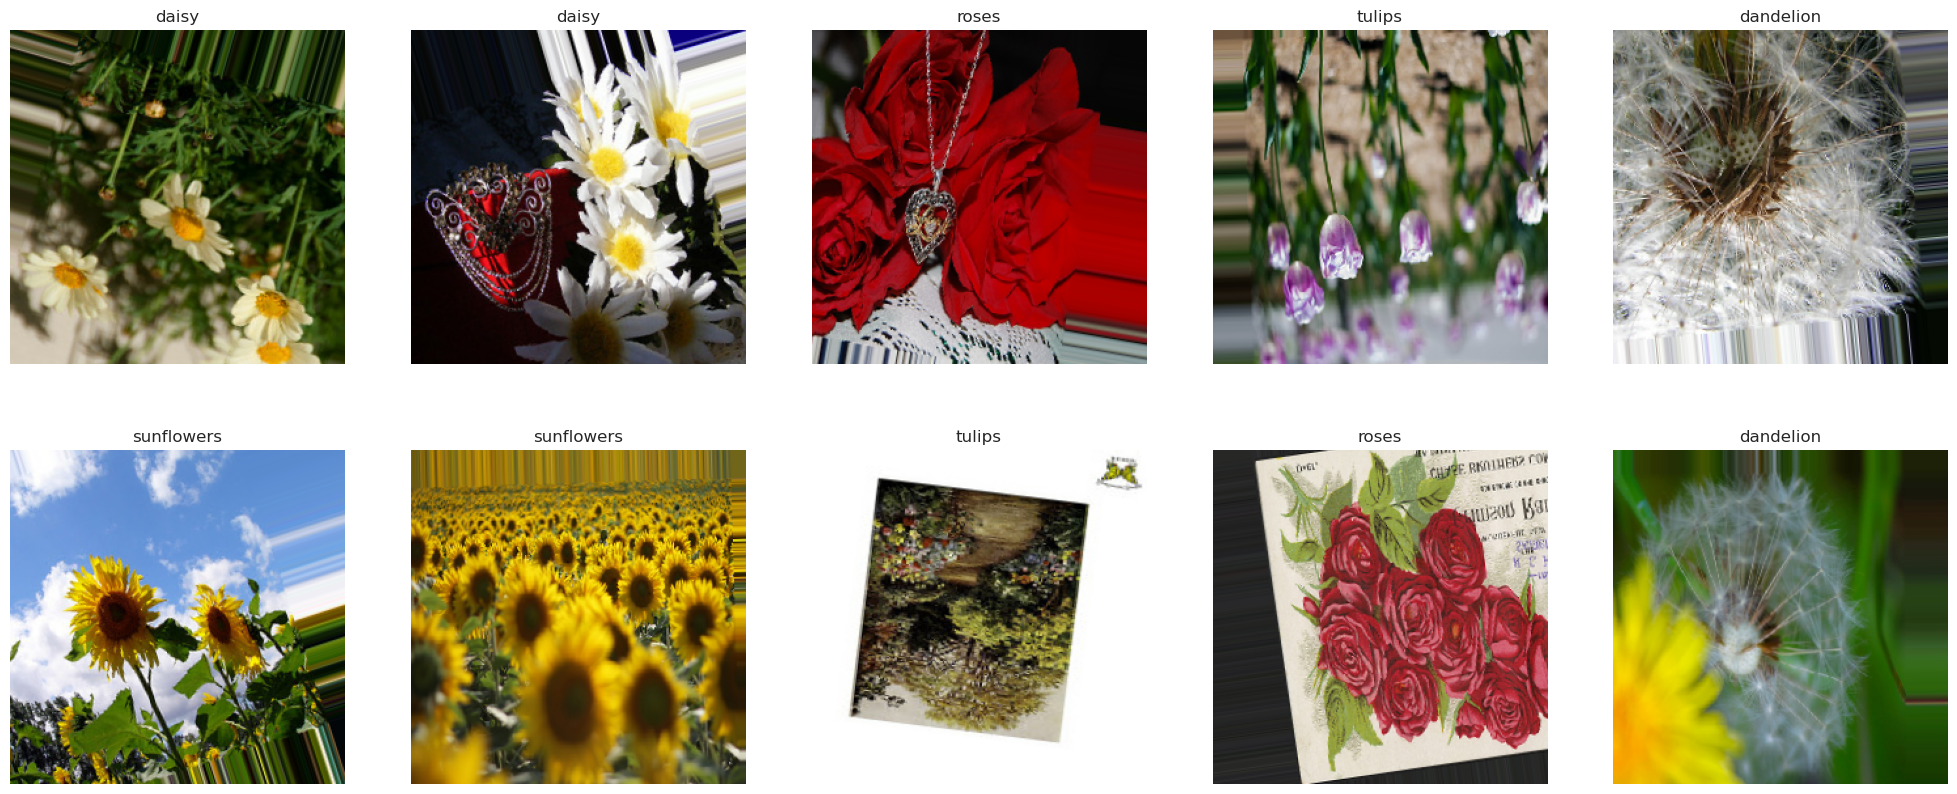

In [ ]:
# Write your code here
plt.figure(figsize=(25, 10))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")

### **D. Load image from URL** <a id="toc-d-load-image-from-url"></a>


In the _Load individual images as PIL objects section_, we saw how we can download images to our working directory and, using the path of the image we saved, use the `load_img` function to return a PIL Image instance.


We can use custom functions like the one below to load images from a URL. This function was  borrowed from [statsmaths](https://statsmaths.github.io/stat289-f18/solutions/tutorial28-keras-images.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01).


In [ ]:
def load_image(link, target_size=None):
    import requests
    import shutil
    import os

    _, ext = os.path.splitext(link)
    r = requests.get(link, stream=True)
    with open("temp." + ext, "wb") as f:
        r.raw.decode_content = True
        shutil.copyfileobj(r.raw, f)
    img = tf.keras.preprocessing.image.load_img(
        "temp." + ext, target_size=target_size
    )
    return tf.keras.preprocessing.image.img_to_array(img)

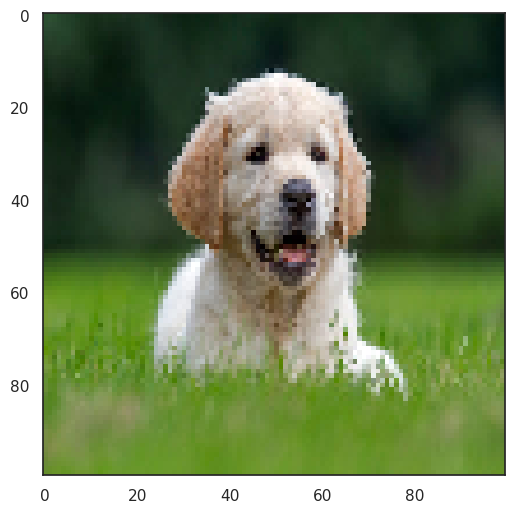

In [ ]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/Dog_Breeds.jpg"

img = load_image(URL, target_size=(100, 100))
plt.imshow(img / 255)

## **Authors**


[Kopal Garg](https://www.linkedin.com/in/gargkopal/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)


Kopal Garg is a Masters student in Computer Science at the University of Toronto.


Su Wu

### **Other Contributors**


[Richard Ye](https://linkedin.com/in/richard-ye?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01), [Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)


## **Change Log**


| Date (YYYY-MM-DD) | Version | Changed By  | Change Description |
| ----------------- | ------- | ----------- | ------------------ |
| 2022-05-23        | 0.1     | Kopal Garg  | Created Lab        |
| 2022-05-23        | 0.1     | Richard Ye  | Load from directory of images        |
| 2022-05-30        | 0.1     | Roxanne Li  | Review and edit content|
| 2022-07-19        | 0.1     | Steve Hord  | QA pass |
|2026-05-18 | Student modification |Su Wu | Added explanatory documentation, code comments, and minor code edits for coursework, learning, and portfolio development|


Copyright © 2022 IBM Corporation. All rights reserved.
